# Log vs Linear Scaling - a visual

**Takeaway up front:** `y = c*x` (multiply by a constant) and `y = log(x)` are *not* lookalikes.
They share only one thing: both go up, so both preserve order. Everything about their **shape** is opposite:

- `c*x` is a **straight line** - constant slope, stays in the *multiplying* world (ratios preserved).
- `log(x)` is a **flattening curve** - shrinking slope, turns *multiplication into addition* (ratios become equal steps).

That opposite shape is exactly why `log` fixes the tiny-number / underflow problem and a constant scale does not.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Shape: straight ray vs bending curve
Plot both over the same range. The linear one is a straight line through the origin, while the
log dives toward minus-infinity near 0, crosses zero at x=1, and flattens as x grows.

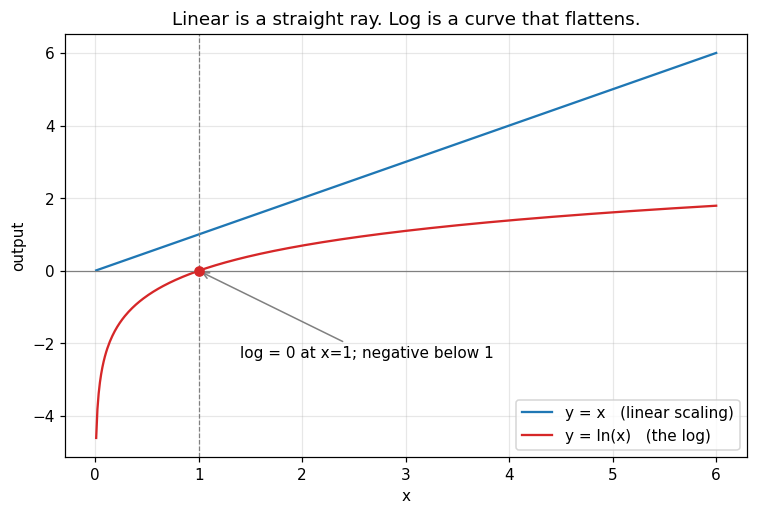

In [2]:
x = np.linspace(0.01, 6, 500)
plt.figure(figsize=(8, 5))
plt.plot(x, x, color='tab:blue', label='y = x   (linear scaling)')
plt.plot(x, np.log(x), color='tab:red', label='y = ln(x)   (the log)')
plt.axhline(0, color='gray', lw=0.8)
plt.axvline(1, color='gray', ls='--', lw=0.8)
plt.scatter([1], [0], color='tab:red', zorder=5)
plt.annotate('log = 0 at x=1; negative below 1', xy=(1, 0), xytext=(1.4, -2.4),
             arrowprops=dict(arrowstyle='->', color='gray'))
plt.title('Linear is a straight ray. Log is a curve that flattens.')
plt.xlabel('x'); plt.ylabel('output'); plt.legend(); plt.grid(alpha=0.3)
plt.show()

## 2. The real difference: feed both equal x10 steps
Take x = 1, 10, 100, 1000, 10000 (each step multiplies the input by 10 - an *equal ratio*). Watch the outputs:

- **linear** keeps multiplying by 10 -> it explodes.
- **log** adds a constant +1 each time -> equal, calm steps.

This is the superpower: log turns 'times 10' into 'plus 1'.

        x    linear = x     log10(x)
         1             1           0
        10            10           1
       100           100           2
      1000          1000           3
     10000         10000           4


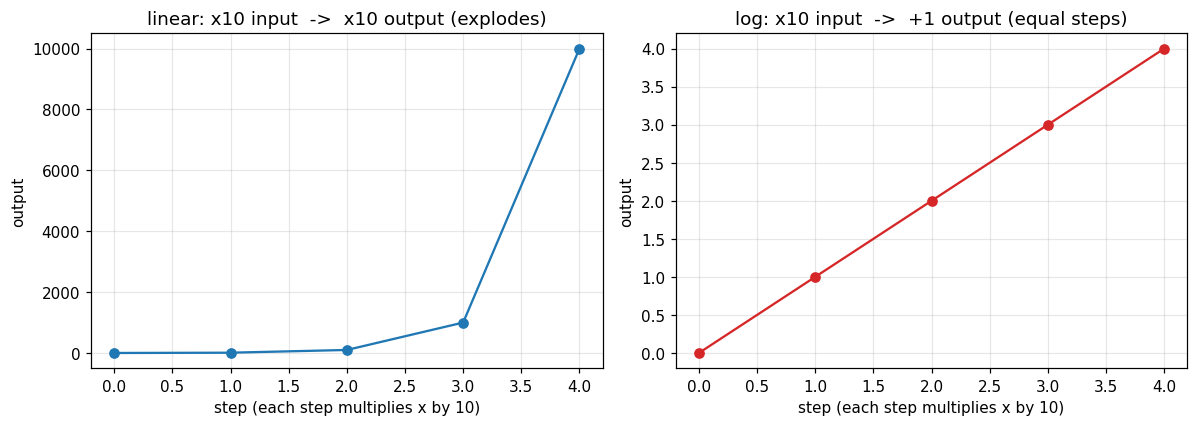

In [3]:
xs = np.array([1, 10, 100, 1000, 10000], dtype=float)
linear = xs
logv = np.log10(xs)

print('        x    linear = x     log10(x)')
for a, b, c in zip(xs, linear, logv):
    print(f'{a:>10.0f}{b:>14.0f}{c:>12.0f}')

steps = np.arange(len(xs))
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(steps, linear, 'o-', color='tab:blue')
ax[0].set_title('linear: x10 input  ->  x10 output (explodes)')
ax[0].set_xlabel('step (each step multiplies x by 10)')
ax[0].set_ylabel('output')
ax[1].plot(steps, logv, 'o-', color='tab:red')
ax[1].set_title('log: x10 input  ->  +1 output (equal steps)')
ax[1].set_xlabel('step (each step multiplies x by 10)')
ax[1].set_ylabel('output')
for a in ax:
    a.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Slope: constant vs always-shrinking
A straight line has ONE slope everywhere. Log's slope is 1/x - steep for small x, gentle for large x,
never constant. The tangent lines below get flatter as x grows. So 'only the slope changes' is backwards:
the line's slope is the fixed thing; the log's slope is what keeps changing.

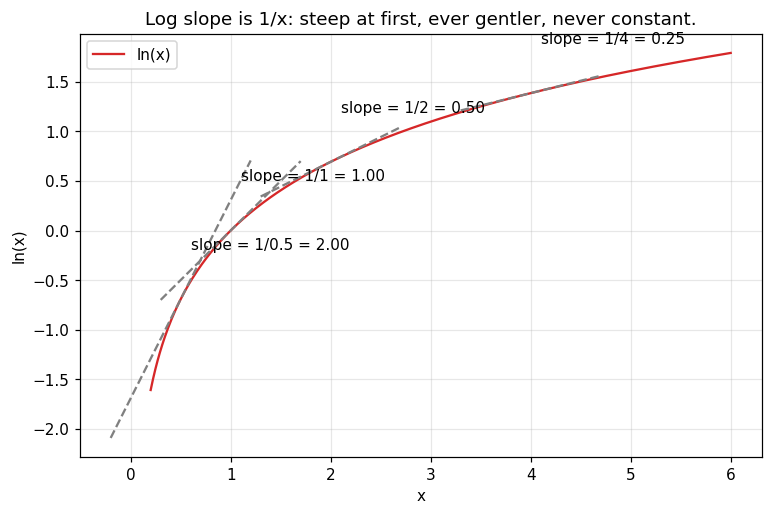

In [4]:
x = np.linspace(0.2, 6, 500)
plt.figure(figsize=(8, 5))
plt.plot(x, np.log(x), color='tab:red', label='ln(x)')
for x0 in [0.5, 1, 2, 4]:
    slope = 1 / x0
    xt = np.linspace(x0 - 0.7, x0 + 0.7, 10)
    yt = np.log(x0) + slope * (xt - x0)
    plt.plot(xt, yt, '--', color='gray')
    plt.annotate(f'slope = 1/{x0:g} = {slope:.2f}', xy=(x0, np.log(x0)),
                 xytext=(x0 + 0.1, np.log(x0) + 0.5))
plt.title('Log slope is 1/x: steep at first, ever gentler, never constant.')
plt.xlabel('x'); plt.ylabel('ln(x)'); plt.grid(alpha=0.3); plt.legend()
plt.show()

## 4. Why this matters for the bigram
Probabilities live in (0, 1]. Log maps that to (-infinity, 0] - everything is <= 0.
Each time a probability gets 10x smaller, its log drops by a fixed step. That fixed step is
'surprise': a rarer event is a constant amount more surprising. Summing these logs over a name,
negating, and averaging gives the average negative log-likelihood loss (~2.45 for the bigram model).

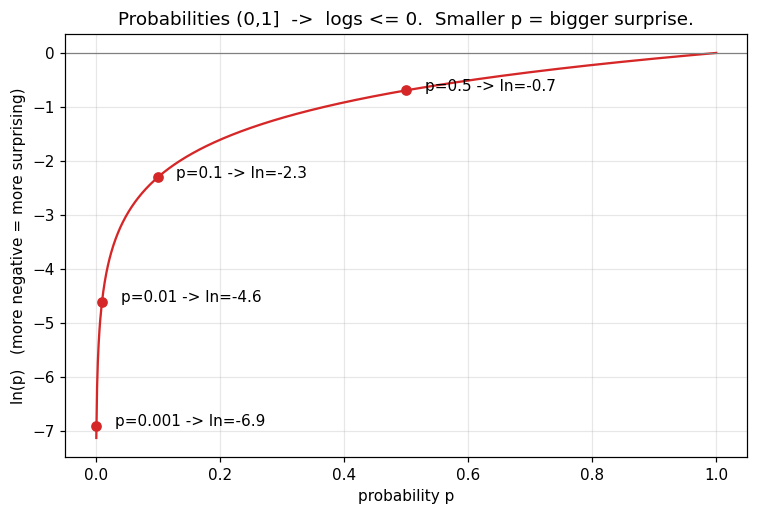

In [5]:
p = np.linspace(0.0008, 1, 800)
plt.figure(figsize=(8, 5))
plt.plot(p, np.log(p), color='tab:red')
for pv in [0.5, 0.1, 0.01, 0.001]:
    if pv >= p.min():
        plt.scatter([pv], [np.log(pv)], color='tab:red', zorder=5)
        plt.annotate(f'p={pv} -> ln={np.log(pv):.1f}', xy=(pv, np.log(pv)),
                     xytext=(pv + 0.03, np.log(pv)))
plt.axhline(0, color='gray', lw=0.8)
plt.title('Probabilities (0,1]  ->  logs <= 0.  Smaller p = bigger surprise.')
plt.xlabel('probability p'); plt.ylabel('ln(p)   (more negative = more surprising)')
plt.grid(alpha=0.3)
plt.show()

## One-liner to keep
`c*x` = straight line, stays multiplicative (ratios preserved).

`log(x)` = flattening curve, turns multiplication into addition (ratios -> equal steps).

Same direction (both increasing), opposite shape. The opposite shape is the whole point.